In [2]:
import tensorflow as tf
from tensorflow.keras import datasets , layers , models , preprocessing


In [3]:
#loading the data
max_ft = 10000
(x_train,y_train) ,(x_test,y_test) = datasets.imdb.load_data(num_words=max_ft)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
#padding to ensure same length
maxlen = 250
x_train = preprocessing.sequence.pad_sequences(x_train,maxlen=maxlen)
x_test = preprocessing.sequence.pad_sequences(x_test,maxlen=maxlen)

In [5]:
x_train[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    1,
         14,   22,   16,   43,  530,  973, 1622, 1385,   65,  458, 4468,
         66, 3941,    4,  173,   36,  256,    5,   25,  100,   43,  838,
        112,   50,  670,    2,    9,   35,  480,  284,    5,  150,    4,
        172,  112,  167,    2,  336,  385,   39,    4,  172, 4536, 1111,
         17,  546,   38,   13,  447,    4,  192,   50,   16,    6,  147,
       2025,   19,   14,   22,    4, 1920, 4613,  469,    4,   22,   71,
         87,   12,   16,   43,  530,   38,   76,   15,   13, 1247,    4,
         22,   17,  515,   17,   12,   16,  626,   18,    2,    5,   62,
        386,   12,    8,  316,    8,  106,    5,    4, 2223, 5244,   16,
        480,   66, 3785,   33,    4,  130,   12,   16,   38,  619,    5,
         25,  124,   51,   36,  135,   48,   25, 14

In [6]:
x_train.shape

(25000, 250)

In [8]:
model = models.Sequential([
    # Layer 1: Word Embedding (turns word numbers into dense vectors)
    layers.Embedding(input_dim=max_ft, output_dim=16, input_length=maxlen),

    # Layer 2: Shrink the data while keeping the meaning
    layers.GlobalAveragePooling1D(),

    # Layer 3: The "Thinking" Layer
    layers.Dense(16, activation='relu'),

    # Layer 4: The Output (Sigmoid because it's Binary: Pos or Neg)
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [11]:

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=512,
    validation_data=(x_test, y_test)
)
model.summary()

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5416 - loss: 0.6913 - val_accuracy: 0.7102 - val_loss: 0.6793
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7032 - loss: 0.6699 - val_accuracy: 0.7357 - val_loss: 0.6342
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7560 - loss: 0.6122 - val_accuracy: 0.7864 - val_loss: 0.5566
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8060 - loss: 0.5281 - val_accuracy: 0.8012 - val_loss: 0.4766
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8330 - loss: 0.4431 - val_accuracy: 0.8289 - val_loss: 0.4158
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8556 - loss: 0.3886 - val_accuracy: 0.8520 - val_loss: 0.3757
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8662 - loss: 0.3455 - val_accuracy: 0.8475 - val_loss: 0.3556
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8759 - loss: 0.3209 - val_accuracy: 0.8654 - v

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 250, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,869 (1.83 MB)

 Trainable params: 160,289 (626.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 320,580 (1.22 MB)

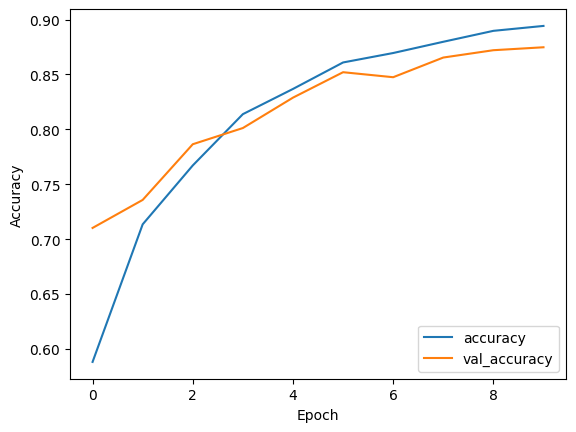

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [13]:
# 1. Get the dictionary that maps words to numbers
word_index = datasets.imdb.get_word_index()

def predict_sentiment(review_text):
    # Preprocess the text: lowercase and split
    words = review_text.lower().split()

    # Convert words to their IMDb integer IDs
    # We add 3 because IMDb reserves 0, 1, and 2 for special tokens
    tokens = []
    for word in words:
        index = word_index.get(word, 2) # Use 2 (unknown) if word not in vocab
        if index + 3 < 10000: # Only keep words within our 10k limit
            tokens.append(index + 3)
        else:
            tokens.append(2)

    # Pad the sequence to length 250
    padded = preprocessing.sequence.pad_sequences([tokens], maxlen=250)

    # Get prediction (0 to 1)
    prediction = model.predict(padded)[0][0]

    sentiment = "POSITIVE" if prediction > 0.5 else "NEGATIVE"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(f"Review: '{review_text}'")
    print(f"Sentiment: {sentiment} ({confidence*100:.2f}% confidence)\n")

# --- TEST IT OUT ---
predict_sentiment("This movie was a masterpiece. The acting was brilliant!")
predict_sentiment("What a total waste of time. The plot made no sense.")
predict_sentiment("It was okay, but I wouldn't watch it again.")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Review: 'This movie was a masterpiece. The acting was brilliant!'
Sentiment: NEGATIVE (54.99% confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Review: 'What a total waste of time. The plot made no sense.'
Sentiment: NEGATIVE (75.07% confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Review: 'It was okay, but I wouldn't watch it again.'
Sentiment: POSITIVE (58.25% confidence)

